In [3]:
import numpy as np
import pandas as pd

In [299]:
# 设置随机种子
np.random.seed(42)

# 生成400个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [529]:
rng_divide=np.random.default_rng(17)

data_train=data.sample(frac=0.67,random_state=rng_divide)
data_test=data.sample(frac=0.33)
data_train.head()

,area,bedrooms,age,location,price
186,172.583330,1,11.660427,6.300838,225.989540
365,107.915396,3,17.035674,7.676982,187.310738
26,79.951067,3,4.251771,5.835698,171.990341
39,116.022874,1,10.003908,9.601881,190.966033
281,100.699274,2,0.936636,9.499153,211.037258


In [301]:
#normalize
Mean=data_train.mean(axis=0)
Std=data_train.std(axis=0)
dataTrain_normalized=(data_train-Mean)/Std  #can be optimized
dataTrain_normalized.head()

,area,bedrooms,age,location,price
186,1.123428,-1.748388,0.232495,0.126271,0.238032
365,-0.307932,0.280045,0.803037,0.843644,-0.588638
26,-0.926894,0.280045,-0.553880,-0.116203,-0.916077
39,-0.128481,-1.748388,0.056667,1.847079,-0.510515
281,-0.467653,-0.734172,-0.905757,1.793528,-0.081539


In [60]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [61]:
def get_loss(y,y_hat):
    return 1/2*pow((y_hat-y),2)

In [62]:
def upgrade_parameter(y,y_hat,x,level_1_to_2,\
              primary_parameter,alph=1):
    
    
    g=y_hat-y
    delta_power2=-alph*g*level_1_to_2
    delta_threshold2=-alph*g

    e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
    delta_power1=-alph*x.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
    delta_threshold1=-alph*(-e)

    primary_parameter['power2']+=delta_power2
    primary_parameter['threshold2']+=delta_threshold2
    primary_parameter['power1']+=delta_power1
    primary_parameter['threshold1']+=delta_threshold1

    return primary_parameter


In [101]:
def standard_BP(data,primary_parameter,loop):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    global loss_sum
    if loop%200==0:
        loss_sum+=get_loss(y,y_hat)
        print(f'mean loss:{(loss_sum/((loop/200)+1)):.6f}')

    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter   

In [403]:
def test_standardBP(data_test,primary_parameter):
    x=data_test.iloc[:-1].values
    y=data_test.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2+primary_parameter['threshold2'][0]

    return y_hat

In [420]:
def test_standardBP(data_test,primary_parameter):
    x=data_test.iloc[:-1].values
    y=data_test.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2+primary_parameter['threshold2'][0]

    return y_hat

In [640]:
#Adaboost with Sigmoid BP,e Error
#

In [404]:
#start

In [505]:
D_1=np.array([1/len(data_train)]*len(data_train))
D_1[:5]

array([0.00373134, 0.00373134, 0.00373134, 0.00373134, 0.00373134])

In [506]:
dataTrain_1=dataTrain_normalized.sample(frac=1,weights=D_1,axis=0,random_state=17)
dataTrain_1=dataTrain_1.sample(frac=1,weights=D_1,axis=0,random_state=17)
dataTrain_1.head()

,area,bedrooms,age,location,price
361,0.545950,-0.734172,-0.858735,-2.275125,-0.640581
273,1.442218,0.280045,-0.986030,-0.478245,1.672914
52,1.529399,0.280045,-0.755099,0.788709,1.834651
332,-1.542043,0.280045,-0.915462,0.551549,-0.326408
245,1.492279,1.294262,0.010353,-0.095812,0.889724


In [507]:
#D_1=pd.DataFrame([1/len(data_train)]*len(data_train),index=dataTrain_1.index,columns=['weights'])
#D_1.head()


In [508]:
rng=np.random.default_rng(17)

primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
print(primary_parameter)

{'power1': array([[0.08450748, 0.01609731, 0.05577445, 0.03680799, 0.0214942 ,
        0.0385824 , 0.04281645],
       [0.06113431, 0.07363859, 0.00152897, 0.02540409, 0.06041459,
        0.00837367, 0.09977637],
       [0.08323461, 0.00367774, 0.05675398, 0.06093401, 0.00069266,
        0.01790839, 0.01649222],
       [0.04619579, 0.05670036, 0.04519092, 0.09197757, 0.08149242,
        0.04011661, 0.02031616]]), 'threshold1': array([0.03583255, 0.0862035 , 0.03488156, 0.09910656, 0.05657688,
       0.02368459, 0.06586973]), 'power2': array([0.06602265, 0.05146076, 0.0279093 , 0.06299182, 0.04791908,
       0.06532888, 0.05422403]), 'threshold2': array([0.01212111])}


In [509]:
loss_sum=0
train_len=len(dataTrain_1)
for j in range(10):
    for i in range(train_len):
        loop=train_len*j+i
        primary_parameter=\
        standard_BP(dataTrain_1.iloc[i],primary_parameter,loop)
print(primary_parameter)

mean loss:0.335834
mean loss:0.171359
mean loss:0.136526
mean loss:0.125209
mean loss:0.177921
mean loss:0.149762
mean loss:0.134921
mean loss:0.132576
mean loss:0.138929
mean loss:0.151402
mean loss:0.140865
mean loss:0.135559
mean loss:0.138585
mean loss:0.130025
{'power1': array([[ 1.43501667,  0.35441107, -0.4972901 ,  0.6550223 ,  0.40913072,
         0.29357774,  0.6125709 ],
       [-0.41039873,  0.36240739, -0.59793815,  0.43849084,  0.39630438,
         0.22296133,  0.67309241],
       [-0.22496343, -0.09665849,  0.28525922, -0.033853  , -0.10814515,
        -0.07922432,  0.02187302],
       [ 0.31327804,  0.31888506, -0.31457743,  0.27802932,  0.33900103,
         0.300214  ,  0.24890239]]), 'threshold1': array([0.25355424, 0.50629756, 0.56970573, 0.4887003 , 0.47118017,
       0.47474559, 0.43937119]), 'power2': array([ 1.35599324,  0.44994186, -0.87808946,  0.76150964,  0.52428707,
        0.3151308 ,  0.85663823]), 'threshold2': array([-1.38029227])}


In [510]:
dataTrain1_preduction=dataTrain_1.apply(test_standardBP,\
                                           axis=1,args=(primary_parameter,))
dataTrain1_preduction.head()

361   -0.353095
273    1.300146
52     1.678476
332   -0.768131
245    1.619921
dtype: float64

In [511]:
np.mean(abs(dataTrain1_preduction-dataTrain_normalized['price']))

np.float64(0.3557760688593842)

In [512]:
wrong=abs(dataTrain_1['price']-dataTrain1_preduction)>0.5  #epsilon need to greater than 0.5?
epsilon=np.sum(wrong*D_1)
print(epsilon)

0.25373134328358204


In [513]:
#if epsilon > n    break

In [514]:
alpha=1/2*np.log((1-epsilon)/epsilon)/np.log(np.e)
alpha

np.float64(0.5394048306859651)

In [515]:
right=abs(dataTrain_1['price']-dataTrain1_preduction)<0.5
value_right=right.astype(int)
value_right[~right]=-1
D_1=(D_1*np.exp(value_right*alpha)).values
D_1[:5]

array([0.0063992 , 0.0063992 , 0.0063992 , 0.0063992 , 0.00217573])

In [688]:
#Here is the formal

In [624]:
rng=np.random.default_rng(17)
train_len=len(data_train)

D_1=np.array([1/len(data_train)]*len(data_train))
dataTrain_1=dataTrain_normalized.sample(frac=1,weights=D_1,axis=0,random_state=17)

list_alpha=[]
list_parameter=[]
number=0

rOrw=0.45

for t in range(13):
    primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
    loss_sum=0
    
    for j in range(10):
        for i in range(train_len):
            loop=train_len*j+i
            primary_parameter=\
            standard_BP(dataTrain_1.iloc[i],primary_parameter,loop)
    print(primary_parameter)
    
    dataTrain1_preduction=dataTrain_1.apply(test_standardBP,\
                                           axis=1,args=(primary_parameter,))

    
    wrong=abs(dataTrain_1['price']-dataTrain1_preduction)>rOrw
    epsilon=np.sum(wrong*D_1)
    # 防止除零错误
    epsilon = max(epsilon, 1e-10)
    print(epsilon)
    
    if epsilon>0.5:
        print("This loop was failed and it restarted\n")
        number+=rng.integers(1,10)
        continue
    
    alpha=1/2*np.log((1-epsilon)/epsilon)  #np.log means ln

    list_parameter.append(primary_parameter)
    list_alpha.append(alpha)

    right=abs(dataTrain_1['price']-dataTrain1_preduction)<rOrw
    value_right=right.astype(int)
    value_right[~right]=-1
    
    D_1=(D_1*np.exp(value_right*alpha)).values  #value_right is a Series ,and the the D_1 become a Series to.
    D_1=D_1/np.sum(D_1)#Although the sample can normalize the weights,but the normalized D_1 will infect the next train
    dataTrain_1=dataTrain_normalized.sample(frac=1,replace=True,weights=D_1,axis=0,random_state=17+number)
    #But if a Series,the index of the weights of sample can't be duplicated
    ##there sample from dataTrain_normalized,not dataTrain_1

mean loss:1.553648
mean loss:0.999741
mean loss:0.667275
mean loss:0.501939
mean loss:0.406909
mean loss:0.394020
mean loss:0.375790
mean loss:0.341647
mean loss:0.332135
mean loss:0.301686
mean loss:0.281660
mean loss:0.261013
mean loss:0.290390
mean loss:0.270086
{'power1': array([[ 1.46384581e+00,  2.11894403e-01, -5.00280016e-01,
         6.77559529e-01,  4.15316390e-01,  5.35092820e-01,
         5.69892966e-01],
       [-3.50235150e-01,  1.75668426e-01, -5.68831008e-01,
         5.76314267e-01,  3.61040624e-01,  3.83040106e-01,
         6.56775201e-01],
       [-2.97858880e-02,  1.30165363e-02,  2.50069383e-01,
         4.16086526e-02, -5.98750161e-03, -9.07191939e-04,
         3.68470088e-02],
       [ 3.48247271e-01,  1.71985695e-01, -4.09664343e-01,
         1.95115039e-01,  2.46964200e-01,  2.38828407e-01,
         1.96120982e-01]]), 'threshold1': array([0.17348347, 0.51973249, 0.52549179, 0.57435657, 0.504609  ,
       0.49012163, 0.54317584]), 'power2': array([ 1.42972674,  

In [625]:
#check

count=len(list_alpha)
print(f"We did {count} basic learner")
alpha_sum=sum(list_alpha)
preduction=pd.Series(np.zeros(len(dataTrain_normalized)),index=dataTrain_normalized.index)


for t in range(count):
    output_alpha=list_alpha[t]/alpha_sum

    preduction+=output_alpha*dataTrain_normalized.apply(test_standardBP,axis=1,args=(list_parameter[t],))


preduction.head()

We did 13 basic learner


186    0.256872
365    0.072013
26    -0.639857
39    -0.022773
281    0.169399
dtype: float64

In [626]:
dataTrain_normalized.head()

,area,bedrooms,age,location,price
186,1.123428,-1.748388,0.232495,0.126271,0.238032
365,-0.307932,0.280045,0.803037,0.843644,-0.588638
26,-0.926894,0.280045,-0.553880,-0.116203,-0.916077
39,-0.128481,-1.748388,0.056667,1.847079,-0.510515
281,-0.467653,-0.734172,-0.905757,1.793528,-0.081539


In [627]:
np.mean(abs(preduction-dataTrain_normalized['price']))

np.float64(0.3516302430406023)

In [628]:
#test

In [629]:
dataTest_normalized=(data_test-Mean)/Std
dataTest_normalized.head()

,area,bedrooms,age,location,price
377,-1.512566,0.280045,-0.885076,-0.967283,-1.470999
215,-0.802140,1.294262,1.747724,0.100370,-0.608760
266,0.724331,-0.734172,-0.715586,-1.691385,-1.225108
38,0.681891,0.280045,-0.082898,-0.735750,0.310818
237,-1.509099,-0.734172,0.364211,2.054616,-0.940648


In [630]:
count=len(list_alpha)
alpha_sum=sum(list_alpha)
test_preduction=pd.Series(np.zeros(len(dataTest_normalized)),index=dataTest_normalized.index)


for t in range(count):
    output_alpha=list_alpha[t]/alpha_sum

    test_preduction+=output_alpha*dataTest_normalized.apply(test_standardBP,axis=1,args=(list_parameter[t],))


test_preduction.head()

377   -1.263202
215   -0.376571
266   -0.268371
38     0.410125
237   -0.727125
dtype: float64

In [631]:
final_testPreduction=test_preduction*Std['price']+Mean['price']
final_testPreduction.name='price_preduction'
#final_testPreduction.head()

In [632]:
result=pd.concat([data_test['price'],final_testPreduction],axis=1)
print(result.head())

          price  price_preduction
377  146.026256        155.748838
215  186.369271        197.233101
266  157.531195        202.295620
38   229.395084        234.041541
237  170.840683        180.831116


In [633]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='price', ylabel='price_preduction'>

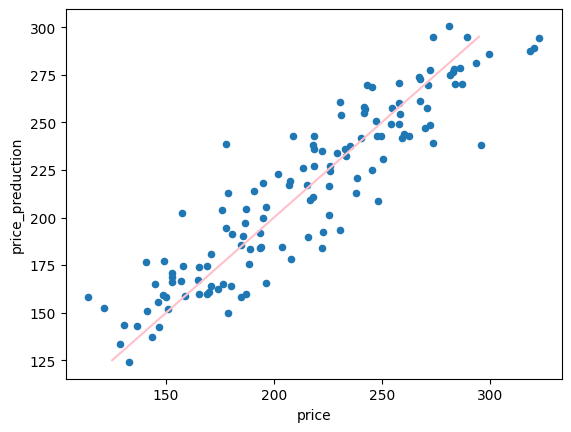

In [634]:
result.plot(kind='scatter',x='price',y='price_preduction')
xy=pd.Series(np.arange(125,300,10),index=np.arange(125,300,10))
xy.plot(kind='line',color='pink')


In [635]:
MeanSqu_error=pow(result['price']-result['price_preduction'],2).mean()
print(f'Mean Squared Error:{MeanSqu_error}')
print(f'Root Mean Squared Error:{pow(MeanSqu_error,0.5)}')

Mean Squared Error:380.267891589744
Root Mean Squared Error:19.50045875331511


In [637]:
#it performed better than just one Sigmoid BP.And if relay on the threshold of right or wrong(rOrw).
#While,this method is not so good.

In [641]:
#bagging

In [646]:
def bagging_standard_BP(data,primary_parameter,loop):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    global bagging_loss_sum
    if loop%1500==0:
        bagging_loss_sum+=get_loss(y,y_hat)
        print(f'mean loss:{(bagging_loss_sum/((loop/1500)+1)):.6f}')

    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter   

In [683]:
rng=np.random.default_rng(17)
bagging_train_len=len(dataTrain_normalized)
bagging_list_parameter=[]

for i in range(50):  #loop 50 or 10 didn't have a great change
    print(f"learner {i}")
    bagging_loss_sum=0
    bagging_train=dataTrain_normalized.sample(frac=1,replace=True)
    bagging_primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
    for j in range(10):
        for i in range(bagging_train_len):
            loop=bagging_train_len*j+i
            bagging_primary_parameter=\
            bagging_standard_BP(bagging_train.iloc[i],bagging_primary_parameter,loop)
    bagging_list_parameter.append(bagging_primary_parameter)
    
    

learner 0
mean loss:0.332520
mean loss:0.240477
learner 1
mean loss:0.387685
mean loss:0.265980
learner 2
mean loss:0.014961
mean loss:0.073152
learner 3
mean loss:0.888248
mean loss:0.446398
learner 4
mean loss:0.009185
mean loss:0.114376
learner 5
mean loss:0.119377
mean loss:0.257458
learner 6
mean loss:0.001570
mean loss:0.152439
learner 7
mean loss:0.022168
mean loss:0.011094
learner 8
mean loss:0.253209
mean loss:0.159462
learner 9
mean loss:0.772351
mean loss:0.425186
learner 10
mean loss:2.110104
mean loss:1.267664
learner 11
mean loss:1.735198
mean loss:0.869027
learner 12
mean loss:0.018109
mean loss:0.074582
learner 13
mean loss:0.448040
mean loss:0.394088
learner 14
mean loss:0.430926
mean loss:0.367413
learner 15
mean loss:0.240990
mean loss:0.152983
learner 16
mean loss:0.440970
mean loss:0.230843
learner 17
mean loss:0.175447
mean loss:0.132894
learner 18
mean loss:0.006035
mean loss:0.043911
learner 19
mean loss:0.096448
mean loss:0.150805
learner 20
mean loss:0.502592


In [656]:
dataTest_normalized.head()

,area,bedrooms,age,location,price
377,-1.512566,0.280045,-0.885076,-0.967283,-1.470999
215,-0.802140,1.294262,1.747724,0.100370,-0.608760
266,0.724331,-0.734172,-0.715586,-1.691385,-1.225108
38,0.681891,0.280045,-0.082898,-0.735750,0.310818
237,-1.509099,-0.734172,0.364211,2.054616,-0.940648


In [684]:
bagging_test_preduction=pd.Series(np.zeros(len(dataTest_normalized)),index=dataTest_normalized.index)
for i in range(50):
    bagging_test_preduction+=dataTest_normalized.apply(test_standardBP,axis=1,args=(bagging_list_parameter[i],))
bagging_test_preduction=bagging_test_preduction/50
bagging_test_preduction.head()

377   -1.281914
215   -0.362407
266   -0.201727
38     0.429604
237   -0.768687
dtype: float64

In [685]:
bagging_final_testPreduction=bagging_test_preduction*Std['price']+Mean['price']
bagging_final_testPreduction.name='bagging_price_preduction'
result=pd.concat([data_test['price'],bagging_final_testPreduction],axis=1)
print(result.head())

          price  bagging_price_preduction
377  146.026256                154.873293
215  186.369271                197.895817
266  157.531195                205.413808
38   229.395084                234.952938
237  170.840683                178.886497


<Axes: xlabel='price', ylabel='bagging_price_preduction'>

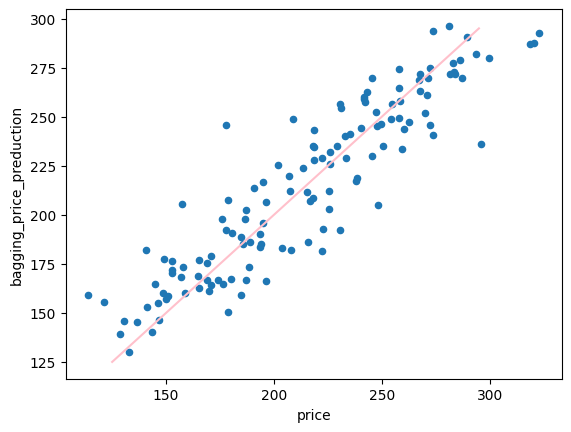

In [686]:
result.plot(kind='scatter',x='price',y='bagging_price_preduction')
xy=pd.Series(np.arange(125,300,10),index=np.arange(125,300,10))
xy.plot(kind='line',color='pink')

In [687]:
MeanSqu_error=pow(result['price']-result['bagging_price_preduction'],2).mean()
print(f'Mean Squared Error:{MeanSqu_error}')
print(f'Root Mean Squared Error:{pow(MeanSqu_error,0.5)}')

Mean Squared Error:394.40549083631873
Root Mean Squared Error:19.859644781222013
